# Chocolate Data Goals
Create a 15 min presesntation for a dataset
1. Clean up data if needed
2. Look for correlations
3. Determine One Hypothesis with data
4. Explore hypothesis
5. Conclude

Thid dataset is from Kaggle and is a summary of worldwide chocolate sales. https://www.kaggle.com/datasets/saidaminsaidaxmadov/chocolate-sales?resource=download

In [1]:
# importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\benpe\OneDrive\Documents\GitHub\Projects\Craft a Story Project\archive (3)\Chocolate Sales (2).csv') # file of interest

In [3]:
df.head(5)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [4]:
df.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


In [6]:
df.describe()

,Boxes Shipped
count,3282.000000
mean,164.666971
std,124.024736
min,1.000000
25%,71.000000
50%,137.000000
75%,232.000000
max,778.000000


In [7]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

In [8]:
print(df['Date'].head())
print(df['Date'].dtype)

0   2022-01-04
1   2022-08-01
2   2022-07-07
3   2022-04-27
4   2022-02-24
Name: Date, dtype: datetime64[ns]
datetime64[ns]


In [9]:
df = df.set_index('Date')

In [10]:
df = df.sort_index()

In [34]:
df.tail(5)

,Sales Person,Country,Product,Amount,Boxes Shipped,Price per Box
Date,,,,,,
2024-08-26,Wilone O'Kielt,UK,Milk Bars,334.81,66,5.072879
2024-08-30,Husein Augar,UK,Eclairs,1955.20,250,7.820800
2024-08-30,Jehu Rudeforth,India,Almond Choco,11793.40,101,116.766337
2024-08-30,Beverie Moffet,New Zealand,85% Dark Bars,12886.26,21,613.631429
2024-08-31,Kaine Padly,India,Spicy Special Slims,6170.80,138,44.715942


In [21]:
df['Amount'] = df['Amount'].replace('[\$,]', '', regex=True).astype(float) 
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3282 entries, 2022-01-03 to 2024-08-31
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sales Person   3282 non-null   object 
 1   Country        3282 non-null   object 
 2   Product        3282 non-null   object 
 3   Amount         3282 non-null   float64
 4   Boxes Shipped  3282 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 153.8+ KB


In [23]:
df['Price per Box'] = df['Amount'] / df['Boxes Shipped']
df.head(5)

,Sales Person,Country,Product,Amount,Boxes Shipped,Price per Box
Date,,,,,,
2022-01-03,Dotty Strutley,USA,Raspberry Choco,3437.0,46,74.717391
2022-01-03,Marney O'Breen,Australia,Smooth Sliky Salty,3745.0,170,22.029412
2022-01-03,Andria Kimpton,Canada,Caramel Stuffed Bars,7154.0,348,20.557471
2022-01-03,Dotty Strutley,UK,99% Dark & Pure,9310.0,282,33.014184
2022-01-03,Camilla Castle,UK,White Choc,9982.0,187,53.379679


In [27]:
price_check = df.groupby('Product')['Price per Box'].agg(['nunique', 'mean', 'std'])
print(price_check.sort_values(by='nunique', ascending=False))

                      nunique        mean         std
Product                                              
50% Dark Bites            180  117.096311  230.929529
Eclairs                   180  124.347012  336.238862
Smooth Sliky Salty        177   92.188668  138.220395
White Choc                174  246.487640  701.867307
Drinking Coco             168   65.306225  118.736945
Spicy Special Slims       162  126.797867  283.221173
Organic Choco Syrup       156   96.722694  217.113562
85% Dark Bars             150  109.348544  205.875900
Fruit & Nut Bars          150  113.930505  339.450524
After Nines               150   77.664147  172.994627
Peanut Butter Cubes       147   96.841860  168.141156
Milk Bars                 147   86.133565  160.096657
99% Dark & Pure           147  155.224428  423.873678
Almond Choco              144   78.719987  112.441715
Raspberry Choco           144   94.285965  160.056498
Orange Choco              141  126.969960  250.317900
Mint Chip Choco           13

In [28]:
pricebycountry_check = df.groupby(['Country', 'Product'])['Price per Box'].agg(['nunique', 'mean', 'std'])
print(pricebycountry_check.sort_values(by='nunique', ascending=False))

                                  nunique        mean         std
Country     Product                                              
Australia   50% Dark Bites             48  167.202710  330.706690
India       Eclairs                    45   65.023530   55.000091
            Spicy Special Slims        42  165.091772  420.454292
New Zealand Mint Chip Choco            42  180.428019  531.730444
UK          50% Dark Bites             36   42.739596   46.818982
...                                   ...         ...         ...
Canada      Mint Chip Choco            12   14.813024   10.081089
India       Manuka Honey Choco         12   36.979591   31.596155
USA         Choco Coated Almonds       12  498.986551  700.931801
            Mint Chip Choco            12  102.895595  119.737821
New Zealand Choco Coated Almonds        9   97.503441   99.401744

[132 rows x 3 columns]


In [30]:
pricebycountry_check = df.groupby(['Country', 'Product', 'Boxes Shipped'])['Price per Box'].agg(['nunique', 'mean', 'std'])
print(pricebycountry_check.sort_values(by='nunique', ascending=False))

                                               nunique        mean         std
Country     Product             Boxes Shipped                                 
New Zealand Eclairs             31                   5  194.856129   33.277481
India       Eclairs             80                   5   62.266875   11.068993
New Zealand Baker's Choco Chips 24                   4  371.503854   82.147473
Canada      Smooth Sliky Salty  12                   4  385.648333  293.315951
USA         Milk Bars           58                   3  186.906379  150.400667
...                                                ...         ...         ...
            White Choc          226                  1   55.624204         NaN
                                218                  1   65.873486         NaN
                                213                  1   57.511737         NaN
                                175                  1   45.145829         NaN
            Spicy Special Slims 261                 

# Question and Hypothesis
- Where is the largest amount of sales growth?
- Hypothesis: This is likely a European country or the USA. 

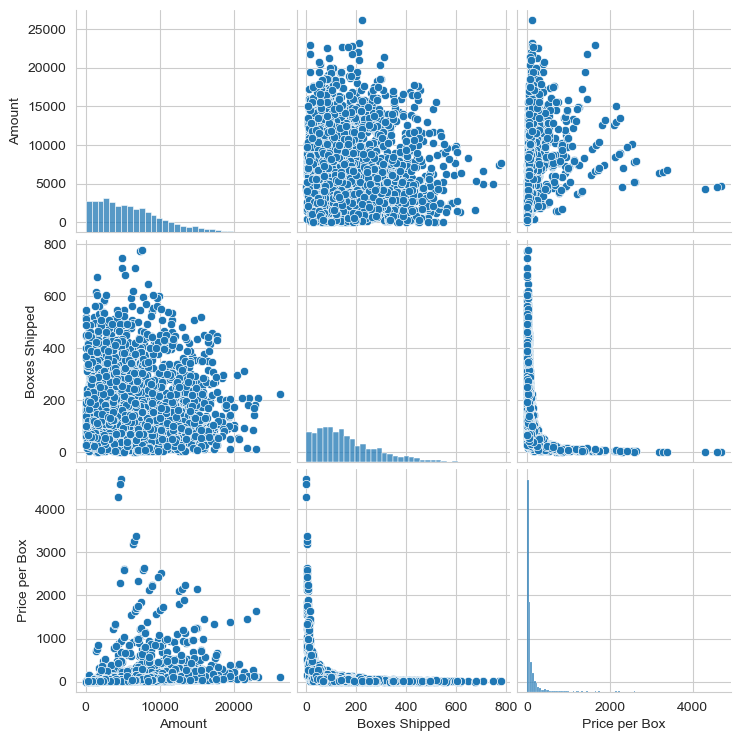

In [49]:
sns.pairplot(data=df)
plt.show()

In [33]:
# Total sales in each country

sales_by_coutry = df.groupby(['Country'])['Amount'].agg(['nunique', 'mean', 'median', 'std'])
print(sales_by_coutry.sort_values(by='median', ascending=False))

             nunique         mean    median          std
Country                                                 
Australia        602  5929.177805  5512.570  4086.100882
UK               529  6302.226404  5491.335  4469.286795
New Zealand      512  5864.458651  5306.480  4219.007194
USA              529  6171.057896  5220.690  4753.879947
Canada           519  5863.801238  4950.210  4148.893930
India            544  6057.483388  4917.235  4668.592783


In [45]:
median_country_month = df.groupby(['Country', pd.Grouper(freq='ME')])['Amount'].median().unstack(level=0)

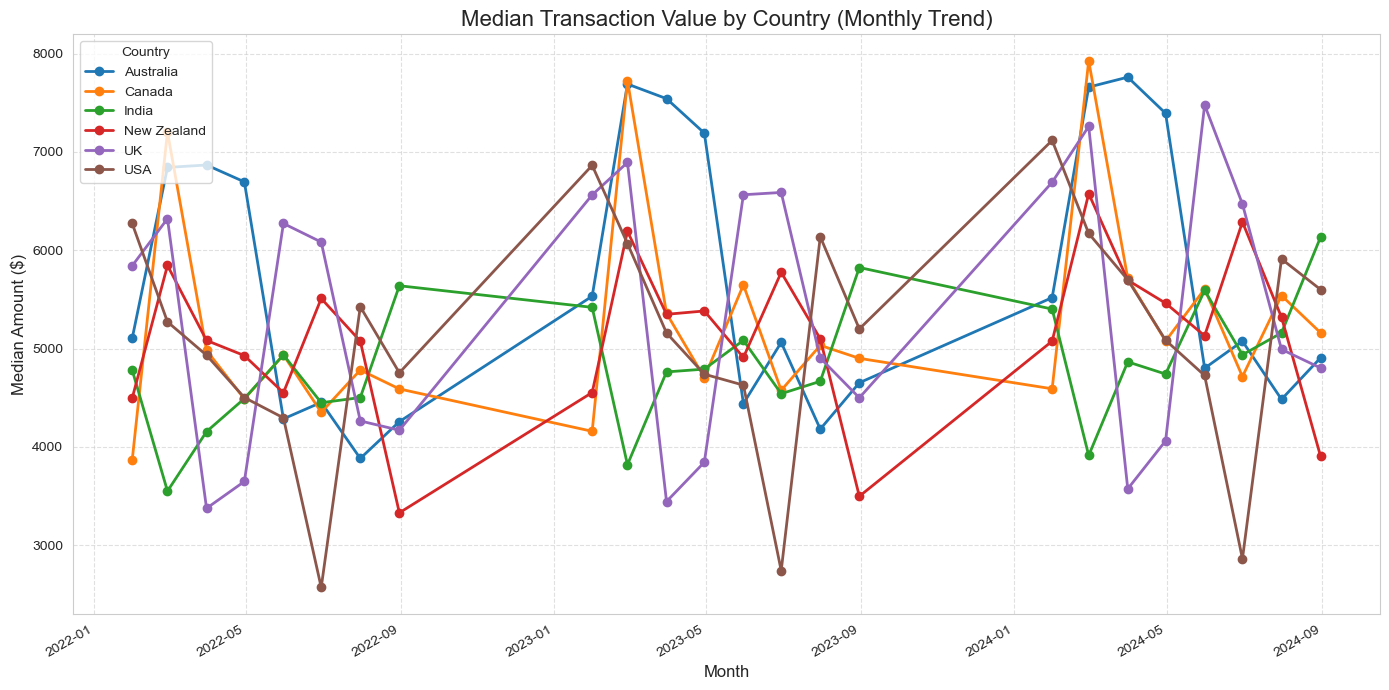

In [46]:
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# We use the unstacked dataframe to plot one line per country
median_country_month.plot(ax=plt.gca(), marker='o', linewidth=2)

plt.title('Median Transaction Value by Country (Monthly Trend)', fontsize=16)
plt.ylabel('Median Amount ($)', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.legend(title='Country', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

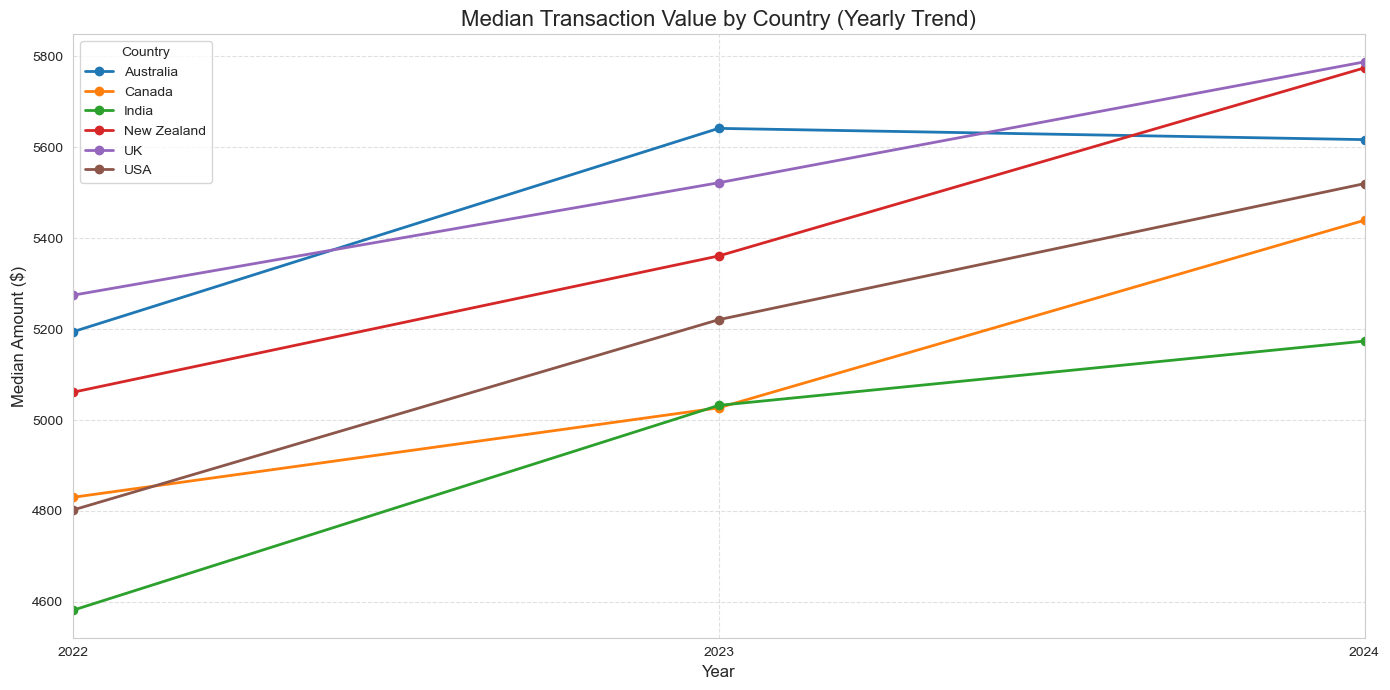

In [47]:
median_country_year = df.groupby(['Country', pd.Grouper(freq='YE')])['Amount'].median().unstack(level=0)
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# We use the unstacked dataframe to plot one line per country
median_country_year.plot(ax=plt.gca(), marker='o', linewidth=2)

plt.title('Median Transaction Value by Country (Yearly Trend)', fontsize=16)
plt.ylabel('Median Amount ($)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(title='Country', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

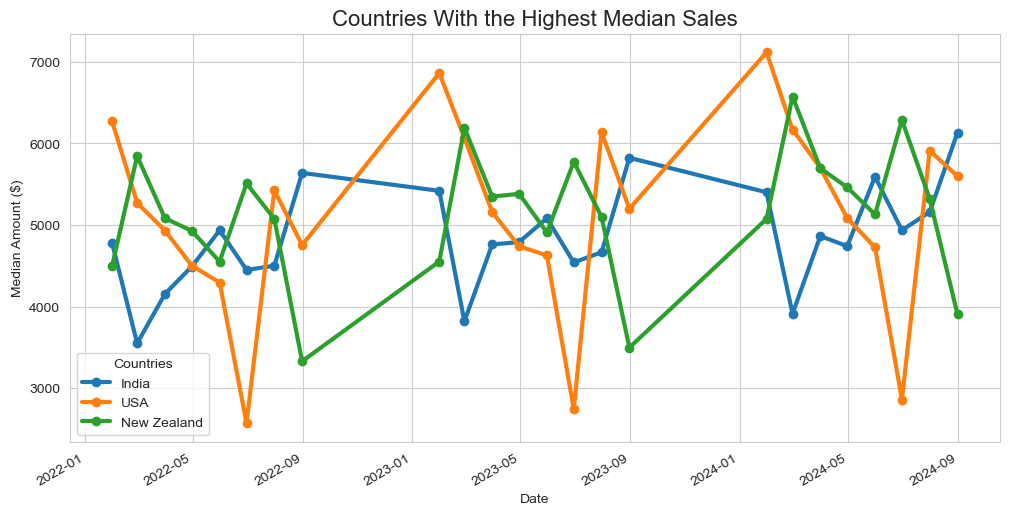

In [50]:
# this is a mess, but looks like there is a small pattern overall with the amount of sales being seasonal.
# Lets focus in on the 3 countries with the largest most recent median

latest_month= median_country_month.index.max()
top_3 = median_country_month.loc[latest_month].nlargest(3).index

# 2. Plot just those three for a cleaner 'Momentum' slide
plt.figure(figsize=(12, 6))
median_country_month[top_3_current].plot(ax=plt.gca(), marker='o', linewidth=3)

plt.title('Countries With the Highest Median Sales', fontsize=16)
plt.ylabel('Median Amount ($)')
plt.legend(title="Countries")
plt.show()

C:\Users\benpe\AppData\Local\Temp\ipykernel_79224\357727530.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  growth_rate = monthly_median.pct_change() * 100


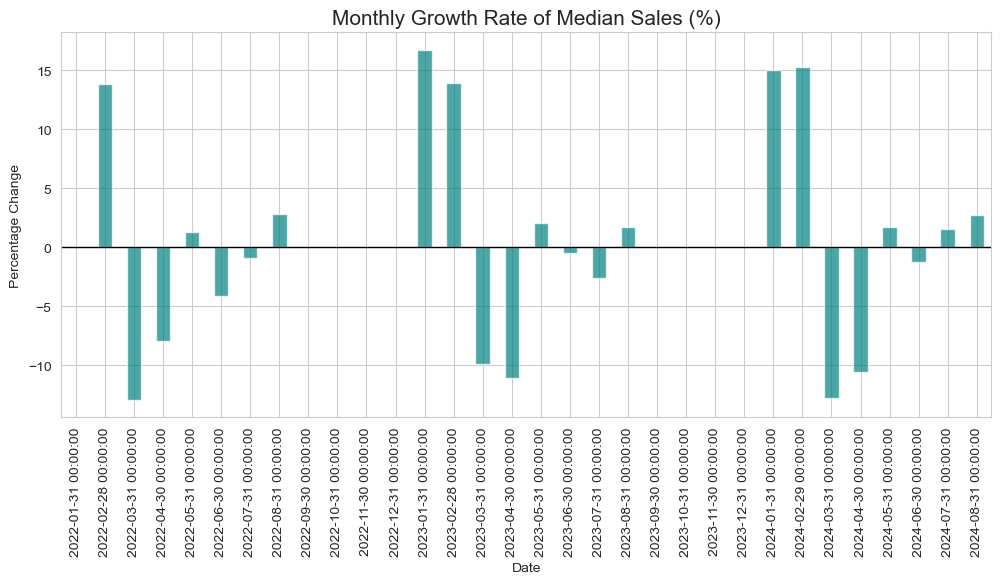

In [39]:
monthly_median = df['Amount'].resample('ME').median()

growth_rate = monthly_median.pct_change() * 100

# 3. Plotting the Rate of Sales
plt.figure(figsize=(12, 5))
growth_rate.plot(kind='bar', color='teal', alpha=0.7)
plt.axhline(0, color='black', linewidth=1) # Baseline
plt.title('Monthly Growth Rate of Median Sales (%)', fontsize=15)
plt.ylabel('Percentage Change')
plt.show()